
# ⚡ Оптимизация резервирования электроэнергии для промышленного предприятия
### Чешский рынок электроэнергии · Солнечные панели · Накопительные батареи · MILP

---

**Цель этого ноутбука** — пошагово объяснить, построить и запустить модель, которая отвечает на вопрос:

> *Сколько мегаватт мощности нужно зарезервировать у сети на следующий месяц, чтобы не переплачивать и не получать штрафы — с учётом солнечных панелей и батарей?*

---

**Структура ноутбука:**

| # | Раздел | Содержание |
|---|--------|-----------|
| 1 | Контекст задачи | Как устроен чешский рынок электроэнергии |
| 2 | Математическая модель | Переменные, ограничения, целевая функция |
| 3 | Данные | Синтетические данные: цены, спрос, солнце |
| 4 | MILP оптимизация | Построение и решение модели (Pyomo + GLPK) |
| 5 | Визуализация | Графики результатов (Seaborn + Matplotlib) |
| 6 | Анализ чувствительности | Как меняется R* при разных конфигурациях |
| 7 | Выводы | Интерпретация результатов |



## 1. Контекст задачи

### 1.1 Как работает чешский рынок электроэнергии

В Чехии оператором оптового рынка является **OTE-CR** (Operátor trhu s elektřinou).  
Регулятор — **ERU** (Energetický regulační úřad).

Промышленное предприятие платит **два вида платежей**:

```
┌─────────────────────────────────────────────────────────┐
│  СЧЁТ ЗА ЭЛЕКТРОЭНЕРГИЮ                                 │
│                                                         │
│  1. Rezervovaný příkon (зарезервированная мощность)     │
│     Фиксированная плата: CZK / MW / месяц               │
│     Платится независимо от того, использована ли        │
│     мощность или нет → ПЕРЕПЛАТА при избытке резерва    │
│                                                         │
│  2. Spotřeba (потреблённая энергия)                     │
│     Переменная плата: CZK / MWh                         │
│     Цена меняется каждые 15 минут (day-ahead рынок)     │
│                                                         │
│  3. Překročení (штраф за превышение)                    │
│     Если факт > резерв → штраф кратный тарифу           │
│     → УБЫТКИ при недостаточном резерве                  │
└─────────────────────────────────────────────────────────┘
```

### 1.2 Почему задача нетривиальная

Предприятие стоит перед **дилеммой**:

- Взять резерв **слишком большой** → переплачиваем каждый месяц за неиспользованную мощность
- Взять резерв **слишком маленький** → штрафы при пиковом потреблении

Задача усложняется тремя факторами неопределённости:

1. **Спрос завода** — меняется в зависимости от производственного графика
2. **Солнечная генерация** — зависит от погоды (облачность, сезон)
3. **Цены OTE** — известны на день вперёд, но меняются каждые 15 минут

### 1.3 Роль батарей и панелей

```
БЕЗ батарей и панелей:          С батареями и панелями:
                                
  Пик спроса = 1.8 MW            Пик спроса = 1.8 MW
  Резерв = 1.8 MW                - Солнце даёт: 0.3 MW
  Штрафы: высокий риск           - Батарея гасит: 0.2 MW
                                 = Из сети нужно: 1.3 MW
                                 Резерв = 1.3 MW ← экономия!
```

Батареи также позволяют **арбитраж по цене**: заряжаться ночью (дёшево) и разряжаться днём (дорого).



## 2. Математическая модель

### 2.1 Обозначения

#### Множества и индексы

| Символ | Описание |
|--------|----------|
| $t \in \mathcal{T} = \{0, 1, \ldots, T-1\}$ | Временные шаги (часы или 15-мин интервалы) |
| $b \in \mathcal{B} = \{0, 1, \ldots, N_B-1\}$ | Батареи (пустое множество если $N_B = 0$) |
| $\omega \in \Omega = \{1, \ldots, S\}$ | Сценарии неопределённости |

#### Параметры (известные величины)

| Символ | Единица | Описание |
|--------|---------|----------|
| $\lambda_t$ | CZK/MWh | Day-ahead цена электроэнергии в момент $t$ (OTE-CR) |
| $D_{t}^{(\omega)}$ | МВт | Потребление завода в момент $t$, сценарий $\omega$ |
| $G_{t}^{(\omega)}$ | МВт | Суммарная солнечная генерация в момент $t$, сценарий $\omega$ |
| $c_R$ | CZK/МВт/день | Тариф за зарезервированную мощность (rezervovaný příkon) |
| $c_\text{pen}$ | CZK/МВт·ч | Штраф за превышение резерва |
| $\Delta t$ | ч | Длительность одного временного шага |
| $R_{\min}, R_{\max}$ | МВт | Допустимый диапазон резервирования (контракт ERU) |
| $E_b^{\max}$ | МВт·ч | Ёмкость батареи $b$ |
| $P_b^{ch}, P_b^{dis}$ | МВт | Максимальная скорость заряда/разряда батареи $b$ |
| $\eta_b^{ch}, \eta_b^{dis}$ | — | КПД заряда и разряда батареи $b$ |

#### Переменные решения

| Символ | Тип | Описание |
|--------|-----|----------|
| $R$ | $\mathbb{R}_{\geq 0}$ | **Зарезервированная мощность** — главное решение |
| $p_t^{(\omega)}$ | $\mathbb{R}_{\geq 0}$ | Потребление из сети в момент $t$, сценарий $\omega$ |
| $\xi_t^{(\omega)}$ | $\mathbb{R}_{\geq 0}$ | Превышение резерва (slack-переменная) |
| $p_{b,t,ch}^{(\omega)}$ | $\mathbb{R}_{\geq 0}$ | Мощность заряда батареи $b$ |
| $p_{b,t,dis}^{(\omega)}$ | $\mathbb{R}_{\geq 0}$ | Мощность разряда батареи $b$ |
| $e_{b,t}^{(\omega)}$ | $\mathbb{R}_{\geq 0}$ | Уровень заряда (SoC) батареи $b$ |

---

### 2.2 Целевая функция

Минимизируем **ожидаемые суммарные затраты**:

$$\min_{R,\, p,\, \xi,\, p_{ch},\, p_{dis},\, e} \quad \underbrace{c_R \cdot R}_{\text{резерв}} \;+\; \frac{1}{S}\sum_{\omega \in \Omega} \sum_{t \in \mathcal{T}} \left[ \underbrace{\lambda_t \cdot p_t^{(\omega)} \cdot \Delta t}_{\text{энергия}} \;+\; \underbrace{c_\text{pen} \cdot \xi_t^{(\omega)}}_{\text{штраф}} \right]$$

Первое слагаемое — **детерминированное** (фиксированная плата за резерв, не зависит от сценария).  
Второе и третье — **стохастические** (усредняются по сценариям через $\frac{1}{S}\sum_\omega$).

---

### 2.3 Ограничения

#### (C1) Баланс мощности — выполняется для каждого $t$ и $\omega$:

$$p_t^{(\omega)} + \sum_{b \in \mathcal{B}} p_{b,t,dis}^{(\omega)} + G_t^{(\omega)} = D_t^{(\omega)} + \sum_{b \in \mathcal{B}} p_{b,t,ch}^{(\omega)} \qquad \forall t, \omega$$

> *Приход (сеть + разряд батарей + солнце) = Расход (завод + заряд батарей)*

#### (C2) Ограничение резерва — «мягкое» через штраф:

$$p_t^{(\omega)} \leq R + \xi_t^{(\omega)}, \quad \xi_t^{(\omega)} \geq 0 \qquad \forall t, \omega$$

> *Если из сети берём больше $R$ — появляется $\xi > 0$, которое штрафуется в целевой функции*

#### (C3) Динамика заряда батарей — уравнение SoC:

$$e_{b,t}^{(\omega)} = e_{b,t-1}^{(\omega)} + \eta_b^{ch} \cdot p_{b,t,ch}^{(\omega)} \cdot \Delta t - \frac{1}{\eta_b^{dis}} \cdot p_{b,t,dis}^{(\omega)} \cdot \Delta t \qquad \forall b, t, \omega$$

> *Текущий заряд = прошлый заряд + заряженное × КПД − разряженное / КПД*

#### (C4) Физические ограничения батарей:

$$0 \leq e_{b,t}^{(\omega)} \leq E_b^{\max} \qquad \forall b, t, \omega$$
$$0 \leq p_{b,t,ch}^{(\omega)} \leq P_b^{ch} \qquad \forall b, t, \omega$$
$$0 \leq p_{b,t,dis}^{(\omega)} \leq P_b^{dis} \qquad \forall b, t, \omega$$

#### (C5) Ограничения резервирования (контракт ERU):

$$R_{\min} \leq R \leq R_{\max}$$

#### (C6) Устойчивость батарей (цикл замыкается):

$$e_{b,T-1}^{(\omega)} \geq e_{b,0}^{(\omega)} \qquad \forall b, \omega$$

> *К концу суток батарея должна быть не менее заряжена, чем в начале — иначе решение «сжигает» батарею*

---

### 2.4 Тип задачи

Это **LP (линейная программа)** — все переменные непрерывные, все ограничения линейные.  
При добавлении бинарных переменных (например, нельзя одновременно заряжать и разряжать) задача становится **MILP**.

$$\text{LP} \xrightarrow{\text{+ бинарные переменные}} \text{MILP}$$

В данной версии мы используем **LP** (без бинарных), что решается очень быстро даже для больших $S$ и $T$.


## 3. Данные

### 3.1 Импорт библиотек

In [1]:
import pyomo
# Стандартные библиотеки
import numpy as np
import pandas as pd
from datetime import datetime

# Оптимизация
import pyomo.environ as pyo

# Визуализация
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import seaborn as sns

# Утилиты
from scipy.ndimage import uniform_filter1d
import warnings
warnings.filterwarnings("ignore")

# Настройка вывода pandas
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", 20)

print("✓ Все библиотеки загружены")
print(f"  numpy  {np.__version__}")
print(f"  pandas {pd.__version__}")
print(f"  seaborn {sns.__version__}")
print(f"  pyomo  {pyomo.__version__}")


✓ Все библиотеки загружены
  numpy  2.3.3
  pandas 2.3.3
  seaborn 0.13.2
  pyomo  6.10.0



### 3.2 Конфигурация модели

Все параметры сосредоточены в одном словаре `CONFIG`.  
**Чтобы изменить конфигурацию** — меняем только этот блок, остальной код не трогаем.


In [2]:
CONFIG = {
    # ── Горизонт планирования ──────────────────────────────────────────────
    "planning_date": datetime(2024, 6, 15),  # летний рабочий день
    "T":  24,           # количество временных шагов (24 часа)
    "dt": 1.0,          # длительность шага в часах (1.0 = часовой шаг)
    "N_scenarios": 30,  # количество стохастических сценариев

    # ── Режим работы завода ────────────────────────────────────────────────
    # "one_shift"  : работа 06-14, остальное — дежурная нагрузка
    # "two_shift"  : работа 06-22, ночь — минимальная нагрузка
    # "continuous" : круглосуточное производство
    "shift_pattern": "two_shift",

    # ── Солнечные панели ───────────────────────────────────────────────────
    "N_panels":     5,      # количество панелей (0 = нет солнца)
    "panel_peak_kw": 100.0, # пиковая мощность одной панели, кВт

    # ── Батареи: список словарей, по одному на каждую батарею ──────────────
    # Чтобы убрать батареи — оставить пустой список: []
    "batteries": [
        {
            "capacity_mwh":     0.5,   # ёмкость, МВт·ч
            "max_charge_mw":    0.25,  # макс. скорость заряда, МВт
            "max_discharge_mw": 0.25,  # макс. скорость разряда, МВт
            "eta_charge":       0.95,  # КПД заряда (η_ch)
            "eta_discharge":    0.95,  # КПД разряда (η_dis)
            "initial_soc":      0.5,   # начальный SoC (доля от ёмкости)
        },
        {
            "capacity_mwh":     0.8,
            "max_charge_mw":    0.40,
            "max_discharge_mw": 0.40,
            "eta_charge":       0.93,
            "eta_discharge":    0.93,
            "initial_soc":      0.5,
        },
    ],

    # ── Тарифы ERU / параметры резерва ────────────────────────────────────
    "R_min":         0.2,    # МВт — минимальный резерв по договору
    "R_max":         5.0,    # МВт — максимальный резерв по договору
    "c_reservation": 450.0,  # CZK/МВт/день — тариф за rezervovaný příkon
    "c_penalty":     2500.0, # CZK/МВт·ч — штраф за превышение резерва
    "allow_export":  True,   # разрешена ли продажа излишков в сеть
}

# Удобные алиасы
T    = CONFIG["T"]
S    = CONFIG["N_scenarios"]
dt   = CONFIG["dt"]
DATE = CONFIG["planning_date"]

print(f"✓ Конфигурация загружена")
print(f"  Горизонт:  {T} часов  ({T*dt:.1f} ч)")
print(f"  Сценарии:  {S}")
print(f"  Батареи:   {len(CONFIG['batteries'])}")
print(f"  Панели:    {CONFIG['N_panels']} × {CONFIG['panel_peak_kw']} кВт")
print(f"  Диапазон R: [{CONFIG['R_min']}, {CONFIG['R_max']}] МВт")


✓ Конфигурация загружена
  Горизонт:  24 часов  (24.0 ч)
  Сценарии:  30
  Батареи:   2
  Панели:    5 × 100.0 кВт
  Диапазон R: [0.2, 5.0] МВт



### 3.3 Генераторы синтетических данных

Каждая функция имеет **одинаковую сигнатуру** — при появлении реальных данных
меняется только тело функции, вся остальная модель остаётся нетронутой.

> **Принцип замены:** `synthetic` → `real` меняется в одном месте


In [3]:
def generate_prices(date: datetime, T: int) -> np.ndarray:
    """
    Синтетические day-ahead цены OTE-CR (CZK/MWh).

    Возвращает: массив shape (T,)

    Реальная замена: GET https://www.ote-cr.cz/cs/kratkodobe-trhy/elektrina/denni-trh
    Данные публично доступны в XML/CSV формате без авторизации.

    Типичный профиль чешских цен:
      - Базовый уровень ~1200 CZK/MWh
      - Утренний пик (08:00) +400 CZK
      - Вечерний пик (18:00) +350 CZK
      - Ночное снижение (02:00) -300 CZK
    """
    np.random.seed(int(date.strftime("%j")))
    hours = np.arange(T)

    base          = 1200
    morning_peak  = 400 * np.exp(-0.5 * ((hours - 8)  / 2) ** 2)
    evening_peak  = 350 * np.exp(-0.5 * ((hours - 18) / 2) ** 2)
    night_dip     = -300 * np.exp(-0.5 * ((hours - 2)  / 3) ** 2)
    noise         = np.random.normal(0, 50, T)

    prices = base + morning_peak + evening_peak + night_dip + noise
    return np.clip(prices, 400, 2500)


def generate_demand_scenarios(date: datetime, T: int, S: int,
                               shift_pattern: str = "two_shift") -> np.ndarray:
    """
    Стохастические сценарии потребления завода (МВт).

    Возвращает: массив shape (S, T)

    Реальная замена: загрузка из CSV умного счётчика или SCADA-системы.
    Структура неопределённости: логнормальный шум (σ=0.12) поверх
    детерминированного профиля смен.

    shift_pattern:
      'one_shift'   → тяжёлая нагрузка 06-14, дежурная ночью
      'two_shift'   → тяжёлая нагрузка 06-22, дежурная ночью
      'continuous'  → равномерная нагрузка 24/7
    """
    np.random.seed(int(date.strftime("%j")) + 42)
    hours = np.arange(T)

    # Базовый профиль по типу смен
    if shift_pattern == "one_shift":
        base = np.where((hours >= 6) & (hours < 14), 1.2, 0.25)
    elif shift_pattern == "two_shift":
        base = np.where((hours >= 6) & (hours < 22), 1.0, 0.3)
    else:
        base = np.full(T, 0.9)

    # Пусковые токи при смене смен (реалистичная деталь)
    for shift_start in [6, 14, 22]:
        if shift_start < T:
            base[shift_start] *= 1.6

    # Генерация сценариев: логнормальный шум, не независимый по времени
    scenarios = np.zeros((S, T))
    for s in range(S):
        noise = np.random.lognormal(mean=0, sigma=0.12, size=T)
        scenarios[s] = base * noise

    return np.clip(scenarios, 0.05, None)


def generate_solar_scenarios(date: datetime, T: int, S: int,
                              panel_peak_kw: float = 100.0) -> np.ndarray:
    """
    Стохастические сценарии солнечной генерации (МВт НА ОДНУ ПАНЕЛЬ).

    Возвращает: массив shape (S, T)
    В модели умножается на N_panels.

    Реальная замена: pvlib + данные PVGIS для координат завода.
    Чехия: lat≈50.0°N, lon≈15.5°E

    Облачность моделируется через коррелированный процесс (Beta-распределение),
    чтобы не было нереалистичных перепадов между соседними часами.
    """
    np.random.seed(int(date.strftime("%j")) + 99)
    hours      = np.arange(T)
    day_of_year = int(date.strftime("%j"))

    # Приближение времени восхода/заката для широты ~50°N
    sunrise = 4 + 3 * np.cos(2 * np.pi * (day_of_year - 172) / 365)
    sunset  = 20 - 3 * np.cos(2 * np.pi * (day_of_year - 172) / 365)

    # Кривая ясного неба (sinusoidal approximation)
    clear_sky = np.where(
        (hours >= sunrise) & (hours <= sunset),
        panel_peak_kw * np.sin(np.pi * (hours - sunrise) / (sunset - sunrise)),
        0.0,
    )
    clear_sky = np.clip(clear_sky, 0, None)

    scenarios = np.zeros((S, T))
    for s in range(S):
        cloud_base   = np.random.beta(3, 1)       # тенденция к ясной/облачной погоде
        cloud_noise  = np.random.uniform(0.7, 1.0, T) * cloud_base
        cloud_smooth = uniform_filter1d(cloud_noise, size=3)  # сглаживание по времени
        scenarios[s] = clear_sky * cloud_smooth / 1000        # кВт → МВт

    return np.clip(scenarios, 0, None)


print("✓ Функции генерации данных определены")


✓ Функции генерации данных определены


### 3.4 Генерация данных и первичный анализ

In [4]:
# ── Генерация ──────────────────────────────────────────────────────────────
prices           = generate_prices(DATE, T)
demand_scenarios = generate_demand_scenarios(DATE, T, S, CONFIG["shift_pattern"])

if CONFIG["N_panels"] > 0:
    solar_per_panel  = generate_solar_scenarios(DATE, T, S, CONFIG["panel_peak_kw"])
    solar_scenarios  = solar_per_panel * CONFIG["N_panels"]
else:
    solar_scenarios  = np.zeros((S, T))

# ── Сводная таблица ────────────────────────────────────────────────────────
hours = np.arange(T)

summary_df = pd.DataFrame({
    "Hour":           hours,
    "Price (CZK/MWh)": prices.round(1),
    "Demand mean (MW)": demand_scenarios.mean(axis=0).round(3),
    "Demand p10 (MW)":  np.percentile(demand_scenarios, 10, axis=0).round(3),
    "Demand p90 (MW)":  np.percentile(demand_scenarios, 90, axis=0).round(3),
    "Solar mean (MW)":  solar_scenarios.mean(axis=0).round(4),
})

print("Первые 12 строк сводной таблицы входных данных:")
print(summary_df.head(12).to_string(index=False))
print(f"\nСтатистика по всем {T} часам:")
print(summary_df[["Price (CZK/MWh)", "Demand mean (MW)", "Solar mean (MW)"]].describe().round(3))


Первые 12 строк сводной таблицы входных данных:
 Hour  Price (CZK/MWh)  Demand mean (MW)  Demand p10 (MW)  Demand p90 (MW)  Solar mean (MW)
    0         895.3000            0.3050           0.2650           0.3540           0.0000
    1         873.7000            0.3120           0.2620           0.3480           0.0000
    2         970.2000            0.3080           0.2630           0.3530           0.0000
    3         933.9000            0.2970           0.2420           0.3440           0.0000
    4        1039.2000            0.2920           0.2420           0.3410           0.0000
    5        1194.1000            0.3000           0.2620           0.3510           0.0000
    6        1354.2000            1.5400           1.2300           1.7710           0.0000
    7        1503.5000            1.0120           0.8730           1.1450           0.0011
    8        1451.0000            0.9820           0.8640           1.1280           0.0962
    9        1422.5000          

### 3.5 Визуализация входных данных

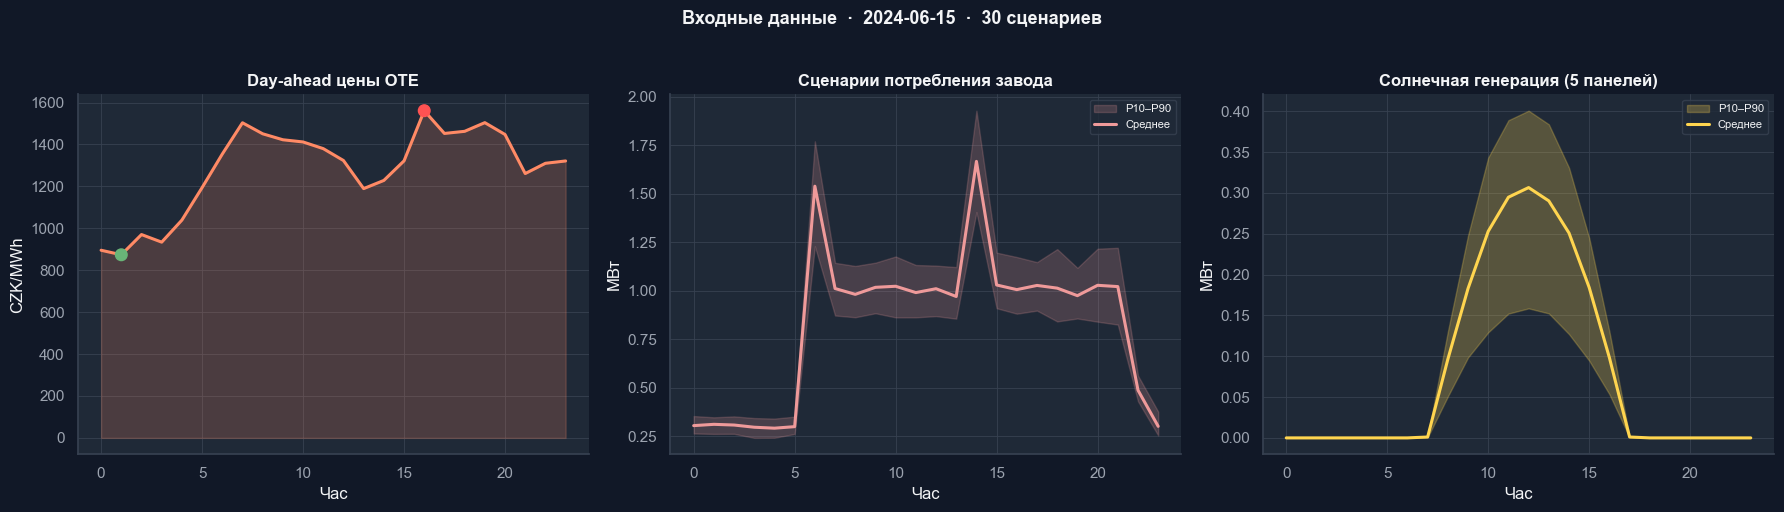

✓ График сохранён: 01_input_data.png


In [5]:
# ── Тема ──────────────────────────────────────────────────────────────────
DARK = {
    "bg":       "#111827",
    "panel":    "#1f2937",
    "grid":     "#374151",
    "text":     "#f3f4f6",
    "sub":      "#9ca3af",
    "price":    "#ff8a65",
    "demand":   "#ef9a9a",
    "solar":    "#ffd54f",
    "reserve":  "#f48fb1",
    "excess":   "#ff5252",
    "bat":      ["#69b578", "#c77dff", "#f4845f", "#48cae4"],
    "grid_col": "#4fc3f7",
}

sns.set_theme(style="darkgrid", context="notebook")
plt.rcParams.update({
    "figure.facecolor": DARK["bg"],  "axes.facecolor":   DARK["panel"],
    "axes.edgecolor":   DARK["grid"],"axes.labelcolor":  DARK["text"],
    "axes.titlecolor":  DARK["text"],"xtick.color":      DARK["sub"],
    "ytick.color":      DARK["sub"], "grid.color":       DARK["grid"],
    "grid.linewidth":   0.6,         "text.color":       DARK["text"],
    "legend.facecolor": DARK["panel"],"legend.edgecolor":DARK["grid"],
    "legend.labelcolor":DARK["text"],"axes.spines.top":  False,
    "axes.spines.right":False,
})

fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor=DARK["bg"])
fig.suptitle(f"Входные данные  ·  {DATE.strftime('%Y-%m-%d')}  ·  {S} сценариев",
             fontsize=13, fontweight="bold", color=DARK["text"], y=1.02)

# ── График 1: Цены ────────────────────────────────────────────────────────
ax = axes[0]
ax.fill_between(hours, prices, alpha=0.2, color=DARK["price"])
sns.lineplot(x=hours, y=prices, ax=ax, color=DARK["price"], linewidth=2.2)
peak_h = int(np.argmax(prices));  low_h = int(np.argmin(prices))
ax.scatter([peak_h, low_h], [prices[peak_h], prices[low_h]],
           color=["#ff5252","#69b578"], zorder=5, s=70)
ax.set_title("Day-ahead цены OTE", fontweight="bold")
ax.set_xlabel("Час");  ax.set_ylabel("CZK/MWh")

# ── График 2: Веер спроса ─────────────────────────────────────────────────
ax = axes[1]
d_mean = demand_scenarios.mean(axis=0)
d_p10  = np.percentile(demand_scenarios, 10, axis=0)
d_p90  = np.percentile(demand_scenarios, 90, axis=0)
ax.fill_between(hours, d_p10, d_p90, alpha=0.2, color=DARK["demand"], label="P10–P90")
sns.lineplot(x=hours, y=d_mean, ax=ax, color=DARK["demand"], linewidth=2.2, label="Среднее")
ax.set_title("Сценарии потребления завода", fontweight="bold")
ax.set_xlabel("Час");  ax.set_ylabel("МВт")
ax.legend(fontsize=8)

# ── График 3: Веер солнца ─────────────────────────────────────────────────
ax = axes[2]
s_mean = solar_scenarios.mean(axis=0)
s_p10  = np.percentile(solar_scenarios, 10, axis=0)
s_p90  = np.percentile(solar_scenarios, 90, axis=0)
ax.fill_between(hours, s_p10, s_p90, alpha=0.25, color=DARK["solar"], label="P10–P90")
sns.lineplot(x=hours, y=s_mean, ax=ax, color=DARK["solar"], linewidth=2.2, label="Среднее")
ax.set_title(f"Солнечная генерация ({CONFIG['N_panels']} панелей)", fontweight="bold")
ax.set_xlabel("Час");  ax.set_ylabel("МВт")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("01_input_data.png", dpi=150, bbox_inches="tight", facecolor=DARK["bg"])
plt.show()
print("✓ График сохранён: 01_input_data.png")



## 4. MILP оптимизация

### 4.1 Построение модели (Pyomo)

Каждый блок кода ниже соответствует конкретному разделу математической модели из секции 2.


In [6]:
def build_model(prices, demand_scenarios, solar_scenarios, battery_params, config):
    """
    Строит и возвращает Pyomo ConcreteModel.

    Структура модели:
      - Множества:    T (время), S (сценарии), B (батареи)
      - Параметры:    цены λ_t, спрос D_{s,t}, солнце G_{s,t}
      - Переменные:   R, p_grid, excess, p_ch, p_dis, e
      - Цел. функция: минимизация CZK (резерв + энергия + штрафы)
      - Ограничения:  C1-C6 из секции 2.3
    """
    S_count, T_count = demand_scenarios.shape
    N_bat            = len(battery_params)

    m = pyo.ConcreteModel(name="MicrogridOptimizer")

    # ── Множества ──────────────────────────────────────────────────────────
    m.T = pyo.RangeSet(0, T_count - 1)
    m.S = pyo.RangeSet(0, S_count - 1)
    # Батареи: пустое множество если N_bat = 0 (модель работает без изменений)
    m.B = pyo.RangeSet(0, N_bat - 1) if N_bat > 0 else pyo.Set(initialize=[])

    # ── Параметры ──────────────────────────────────────────────────────────
    m.price  = pyo.Param(m.T, initialize=lambda m, t: float(prices[t]))
    m.demand = pyo.Param(m.S, m.T,
                         initialize=lambda m, s, t: float(demand_scenarios[s, t]))
    m.solar  = pyo.Param(m.S, m.T,
                         initialize=lambda m, s, t: float(solar_scenarios[s, t]))

    c_res        = config["c_reservation"]
    c_pen        = config["c_penalty"]
    allow_export = config["allow_export"]

    # ── Переменные решения ─────────────────────────────────────────────────

    # R — главная переменная: сколько МВт зарезервировать
    m.R = pyo.Var(within=pyo.NonNegativeReals,
                  bounds=(config["R_min"], config["R_max"]))

    # p_grid — потребление из сети по каждому сценарию и часу
    m.p_grid = pyo.Var(m.S, m.T, within=pyo.NonNegativeReals)

    # excess (ξ) — превышение резерва: мягкое ограничение через штраф
    m.excess = pyo.Var(m.S, m.T, within=pyo.NonNegativeReals)

    # Опционально: продажа излишков солнца в сеть
    if allow_export:
        m.p_export = pyo.Var(m.S, m.T, within=pyo.NonNegativeReals)

    # Переменные батарей — создаются только если есть батареи
    if N_bat > 0:
        m.p_ch  = pyo.Var(m.B, m.S, m.T, within=pyo.NonNegativeReals)  # заряд
        m.p_dis = pyo.Var(m.B, m.S, m.T, within=pyo.NonNegativeReals)  # разряд
        m.e     = pyo.Var(m.B, m.S, m.T, within=pyo.NonNegativeReals)  # SoC

    # ── Целевая функция ────────────────────────────────────────────────────
    # Соответствует формуле из секции 2.2
    def obj_rule(m):
        cost_res    = c_res * m.R                              # фикс. плата за резерв
        cost_energy = 0
        cost_pen    = 0
        rev_export  = 0

        for s in m.S:
            for t in m.T:
                cost_energy += m.price[t] * m.p_grid[s, t] * dt    # λ_t · p_t · Δt
                cost_pen    += c_pen * m.excess[s, t]               # штраф за ξ
                if allow_export:
                    # Продажа по 80% от закупочной цены
                    rev_export += m.price[t] * m.p_export[s, t] * dt * 0.8

        # Усреднение по сценариям (E[·] = (1/S)·Σ_ω)
        return cost_res + (cost_energy + cost_pen - rev_export) / S_count

    m.obj = pyo.Objective(rule=obj_rule, sense=pyo.minimize)

    # ── Ограничение C1: Баланс мощности ───────────────────────────────────
    def balance_rule(m, s, t):
        bat_dis = sum(m.p_dis[b, s, t] for b in m.B) if N_bat > 0 else 0
        bat_ch  = sum(m.p_ch[b, s, t]  for b in m.B) if N_bat > 0 else 0
        export  = m.p_export[s, t] if allow_export else 0
        # сеть + разряд + солнце = спрос + заряд + экспорт
        return m.p_grid[s,t] + bat_dis + m.solar[s,t] == m.demand[s,t] + bat_ch + export

    m.balance = pyo.Constraint(m.S, m.T, rule=balance_rule)

    # ── Ограничение C2: Резерв ─────────────────────────────────────────────
    def reserve_rule(m, s, t):
        return m.p_grid[s, t] <= m.R + m.excess[s, t]  # p ≤ R + ξ

    m.reserve = pyo.Constraint(m.S, m.T, rule=reserve_rule)

    # ── Ограничения C3-C6: Батареи ─────────────────────────────────────────
    if N_bat > 0:

        # C3: Динамика SoC: e_t = e_{t-1} + η_ch·p_ch·Δt - (1/η_dis)·p_dis·Δt
        def soc_rule(m, b, s, t):
            bp     = battery_params[b]
            e_prev = (bp["initial_soc"] * bp["capacity_mwh"]
                      if t == 0 else m.e[b, s, t - 1])
            return (m.e[b, s, t] == e_prev
                    + bp["eta_charge"]      * m.p_ch[b, s, t]  * dt
                    - (1/bp["eta_discharge"])* m.p_dis[b, s, t] * dt)

        m.soc_dyn = pyo.Constraint(m.B, m.S, m.T, rule=soc_rule)

        # C4a: Ёмкость: 0 ≤ e ≤ E_max
        m.soc_max = pyo.Constraint(
            m.B, m.S, m.T,
            rule=lambda m, b, s, t: m.e[b, s, t] <= battery_params[b]["capacity_mwh"]
        )

        # C4b: Макс. скорость заряда: p_ch ≤ P_ch
        m.ch_max = pyo.Constraint(
            m.B, m.S, m.T,
            rule=lambda m, b, s, t: m.p_ch[b, s, t] <= battery_params[b]["max_charge_mw"]
        )

        # C4c: Макс. скорость разряда: p_dis ≤ P_dis
        m.dis_max = pyo.Constraint(
            m.B, m.S, m.T,
            rule=lambda m, b, s, t: m.p_dis[b, s, t] <= battery_params[b]["max_discharge_mw"]
        )

        # C6: Устойчивость цикла: e_{T-1} ≥ e_0
        m.soc_cycle = pyo.Constraint(
            m.B, m.S,
            rule=lambda m, b, s: (
                m.e[b, s, T_count - 1] >=
                battery_params[b]["initial_soc"] * battery_params[b]["capacity_mwh"]
            )
        )

    return m


print("✓ Функция build_model() определена")


✓ Функция build_model() определена


### 4.2 Решение модели

In [7]:
print("Строим модель...")
model = build_model(
    prices           = prices,
    demand_scenarios = demand_scenarios,
    solar_scenarios  = solar_scenarios,
    battery_params   = CONFIG["batteries"],
    config           = CONFIG,
)

# ── Выбор решателя: пробуем доступные по приоритету ───────────────────────
def get_solver():
    """Возвращает первый доступный решатель из списка приоритетов."""
    candidates = [
        ("appsi_highs", "HiGHS (pip install highspy)"),
        ("glpk",        "GLPK (conda install -c conda-forge glpk)"),
        ("cbc",         "CBC  (conda install -c conda-forge coincbc)"),
        ("cplex",       "CPLEX"),
        ("gurobi",      "Gurobi"),
    ]
    for name, hint in candidates:
        slv = pyo.SolverFactory(name)
        if slv.available():
            print(f"✓ Используем решатель: {name}")
            return slv
    raise RuntimeError(
        "Не найден ни один поддерживаемый решатель.\n"
        "Установите один из:\n"
        "  pip install highspy\n"
        "  conda install -c conda-forge glpk\n"
        "  conda install -c conda-forge coincbc"
    )

print("Решаем...")
solver = get_solver()
result = solver.solve(model, tee=False)

status = str(result.solver.termination_condition)
print(f"\nСтатус решения: {status}")
assert status in ("optimal", "feasible"), f"Решатель не нашёл оптимум: {status}"

# ── Извлечение результатов ────────────────────────────────────────────────
R_opt     = pyo.value(model.R)
total_czk = pyo.value(model.obj)
N_bat     = len(CONFIG["batteries"])

p_grid_mean = np.array([
    np.mean([pyo.value(model.p_grid[s, t]) for s in range(S)]) for t in range(T)
])
excess_mean = np.array([
    np.mean([pyo.value(model.excess[s, t]) for s in range(S)]) for t in range(T)
])

batteries_out = []
if N_bat > 0:
    for b in range(N_bat):
        batteries_out.append({
            "id":           b,
            "soc_mwh":      np.array([np.mean([pyo.value(model.e[b, s, t])     for s in range(S)]) for t in range(T)]),
            "charge_mw":    np.array([np.mean([pyo.value(model.p_ch[b, s, t])  for s in range(S)]) for t in range(T)]),
            "discharge_mw": np.array([np.mean([pyo.value(model.p_dis[b, s, t]) for s in range(S)]) for t in range(T)]),
        })

# ── Вывод ключевых результатов ─────────────────────────────────────────────
print(f"""
╔══════════════════════════════════════════╗
║           РЕЗУЛЬТАТЫ ОПТИМИЗАЦИИ         ║
╠══════════════════════════════════════════╣
║  Оптимальный резерв R*  : {R_opt:.3f} МВт    ║
║  Суммарные затраты/день : {total_czk:>10,.0f} CZK ║
║  Оценка на месяц        : {total_czk*30:>10,.0f} CZK ║
╠══════════════════════════════════════════╣
║  Макс. превышение резерва: {excess_mean.max():.4f} МВт   ║
║  Ср. превышение за день  : {excess_mean.mean():.6f} МВт ║
╚══════════════════════════════════════════╝""")

if batteries_out:
    print("\nДиспетчеризация батарей:")
    for bat in batteries_out:
        charged    = bat["charge_mw"].sum() * dt
        discharged = bat["discharge_mw"].sum() * dt
        cap        = CONFIG["batteries"][bat["id"]]["capacity_mwh"]
        print(f"  Батарея {bat['id']} ({cap} МВт·ч): "
              f"заряжено {charged:.2f} МВт·ч, разряжено {discharged:.2f} МВт·ч")


Строим модель...
Решаем...
✓ Используем решатель: appsi_highs

Статус решения: optimal

╔══════════════════════════════════════════╗
║           РЕЗУЛЬТАТЫ ОПТИМИЗАЦИИ         ║
╠══════════════════════════════════════════╣
║  Оптимальный резерв R*  : 1.353 МВт    ║
║  Суммарные затраты/день :     24,394 CZK ║
║  Оценка на месяц        :    731,818 CZK ║
╠══════════════════════════════════════════╣
║  Макс. превышение резерва: 0.0001 МВт   ║
║  Ср. превышение за день  : 0.000002 МВт ║
╚══════════════════════════════════════════╝

Диспетчеризация батарей:
  Батарея 0 (0.5 МВт·ч): заряжено 1.06 МВт·ч, разряжено 0.96 МВт·ч
  Батарея 1 (0.8 МВт·ч): заряжено 0.94 МВт·ч, разряжено 0.81 МВт·ч


### 4.3 Таблица почасовых результатов

In [8]:
# Строим подробную таблицу по каждому часу
results_df = pd.DataFrame({
    "Час":                hours,
    "Цена (CZK/MWh)":     prices.round(1),
    "Спрос среднее (МВт)":demand_scenarios.mean(axis=0).round(3),
    "Солнце среднее (МВт)":solar_scenarios.mean(axis=0).round(4),
    "Из сети (МВт)":      p_grid_mean.round(4),
    "Превышение (МВт)":   excess_mean.round(6),
    "Резерв R* (МВт)":    R_opt,
    "Стоимость (CZK)":    (prices * p_grid_mean * dt).round(1),
})

if batteries_out:
    for bat in batteries_out:
        cap = CONFIG["batteries"][bat["id"]]["capacity_mwh"]
        results_df[f"Бат{bat['id']} SoC (%)"]  = (bat["soc_mwh"] / cap * 100).round(1)
        results_df[f"Бат{bat['id']} заряд (МВт)"]  = bat["charge_mw"].round(3)
        results_df[f"Бат{bat['id']} разряд (МВт)"] = bat["discharge_mw"].round(3)

print("Почасовые результаты оптимизации:")
print(results_df.to_string(index=False))
print(f"\nИТОГО за день: {results_df['Стоимость (CZK)'].sum():,.0f} CZK (только энергия)")


Почасовые результаты оптимизации:
 Час  Цена (CZK/MWh)  Спрос среднее (МВт)  Солнце среднее (МВт)  Из сети (МВт)  Превышение (МВт)  Резерв R* (МВт)  Стоимость (CZK)  Бат0 SoC (%)  Бат0 заряд (МВт)  Бат0 разряд (МВт)  Бат1 SoC (%)  Бат1 заряд (МВт)  Бат1 разряд (МВт)
   0        895.3000               0.3050                0.0000         0.3484            0.0000           1.3530         311.9000       52.5000            0.0130             0.0000       53.5000            0.0300             0.0000
   1        873.7000               0.3120                0.0000         0.9618            0.0000           1.3530         840.3000      100.0000            0.2500             0.0000      100.0000            0.4000             0.0000
   2        970.2000               0.3080                0.0000         0.3082            0.0000           1.3530         299.0000      100.0000            0.0000             0.0000      100.0000            0.0000             0.0000
   3        933.9000              

## 5. Визуализация результатов

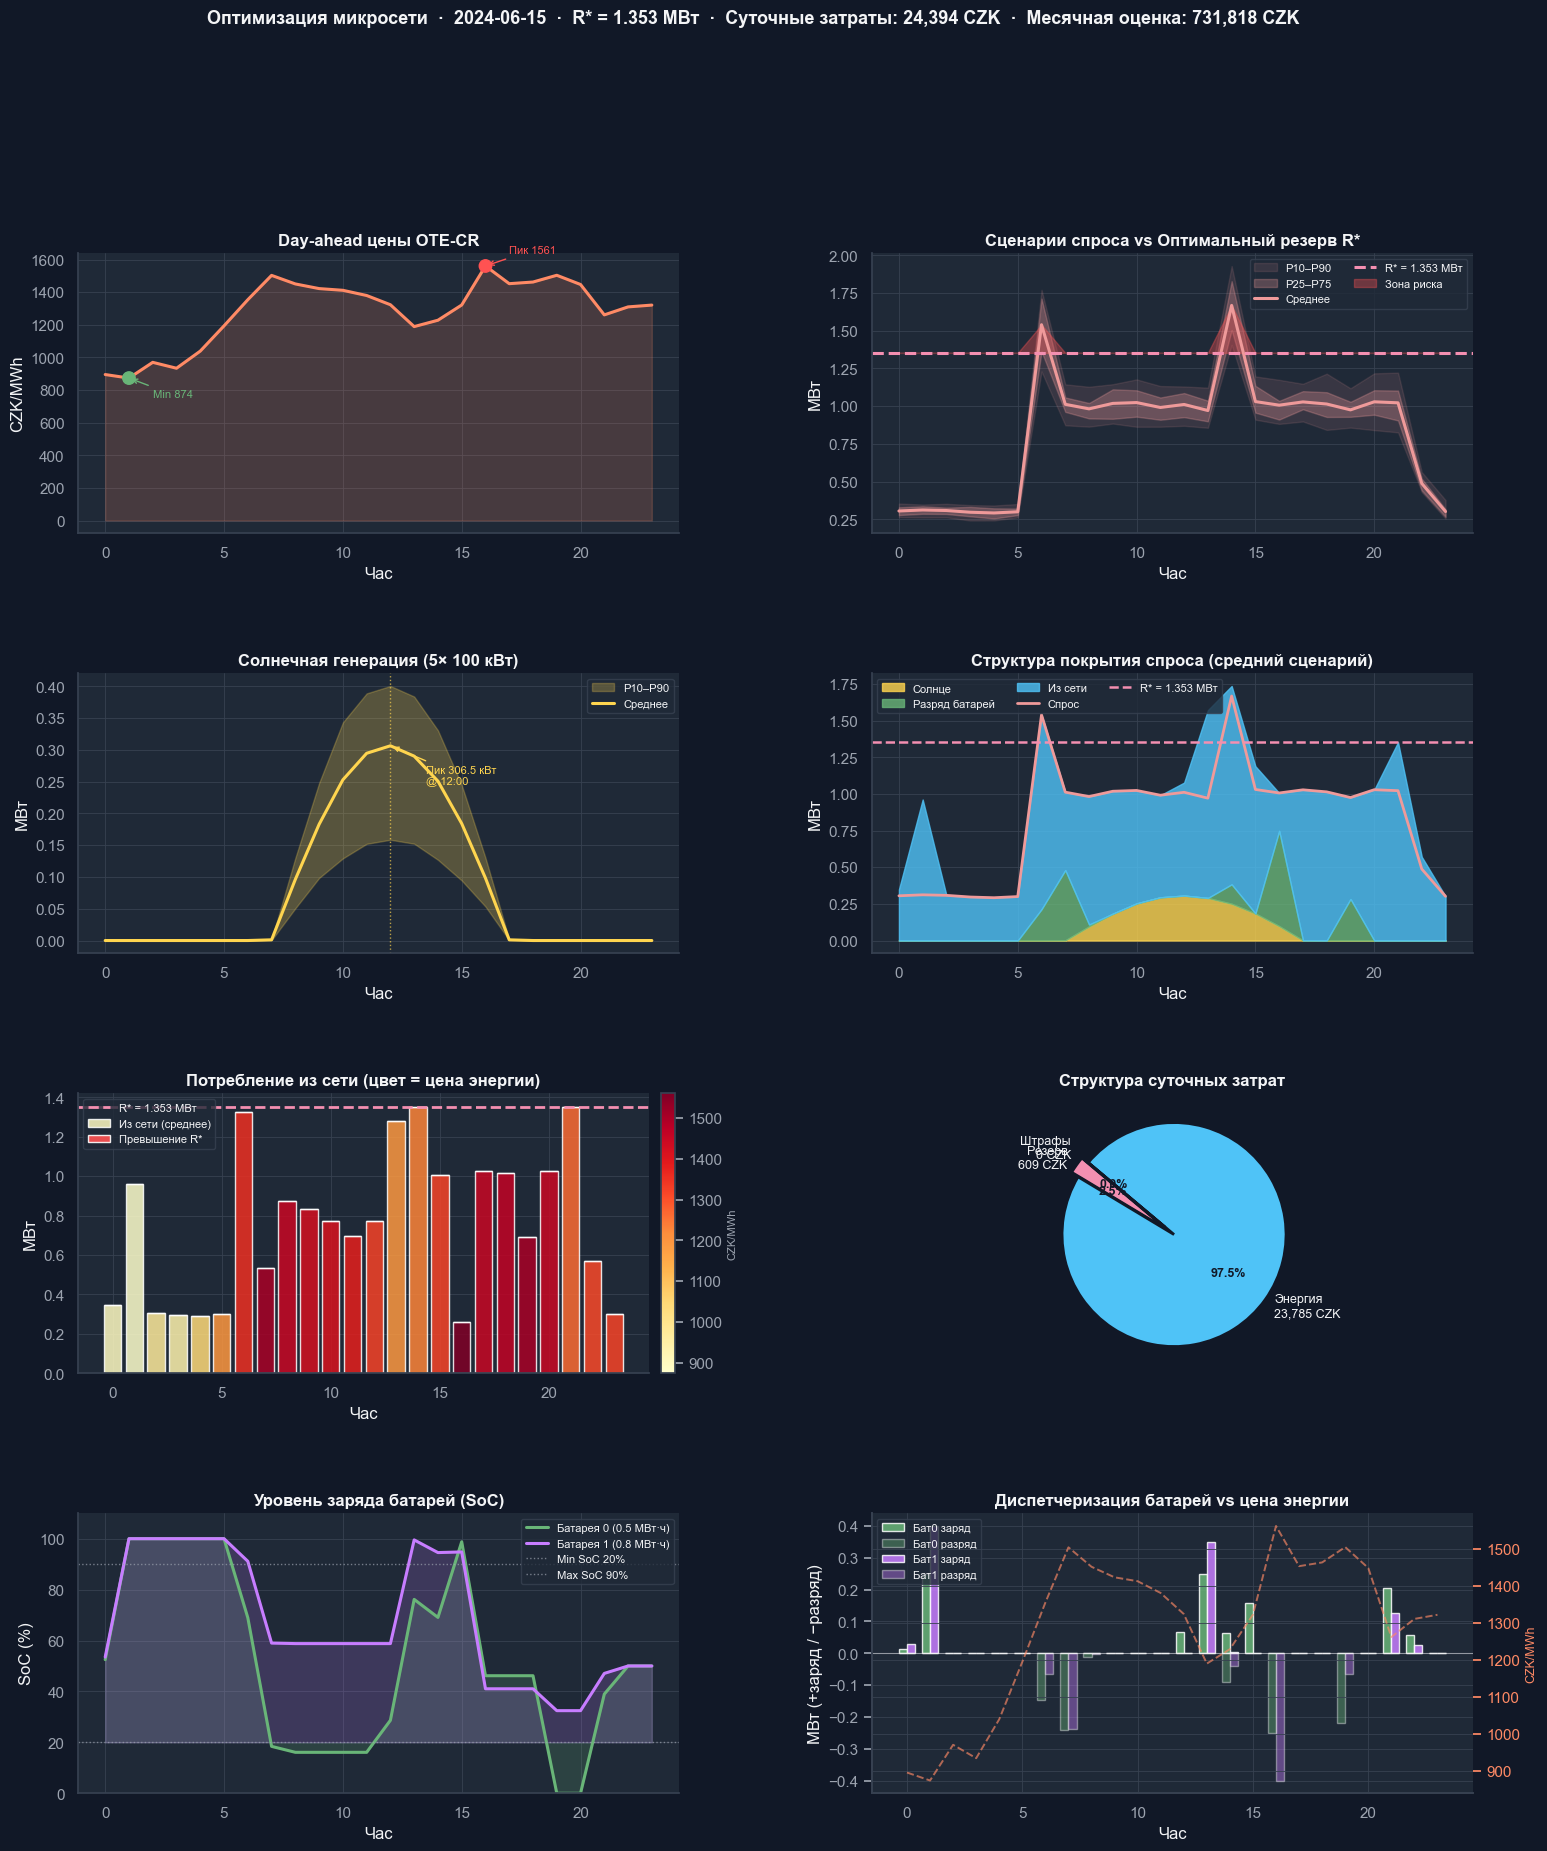

✓ График сохранён: 02_optimization_results.png


In [9]:
fig = plt.figure(figsize=(18, 20), facecolor=DARK["bg"])
gs  = gridspec.GridSpec(4, 2, figure=fig, hspace=0.50, wspace=0.32)

# ═════════════════════════════════════════════════════════════════════════════
# ПАНЕЛЬ 1: Цены с аннотациями
# ═════════════════════════════════════════════════════════════════════════════
ax1 = fig.add_subplot(gs[0, 0])
ax1.fill_between(hours, prices, alpha=0.18, color=DARK["price"])
sns.lineplot(x=hours, y=prices, ax=ax1, color=DARK["price"], linewidth=2.2)
# Аннотируем пик и минимум — это часы когда батарея должна разряжаться/заряжаться
pk, lw = int(np.argmax(prices)), int(np.argmin(prices))
ax1.scatter([pk, lw], [prices[pk], prices[lw]], color=["#ff5252","#69b578"], s=80, zorder=5)
ax1.annotate(f"Пик {prices[pk]:.0f}", xy=(pk, prices[pk]),
             xytext=(pk+1, prices[pk]+80), color="#ff5252", fontsize=8,
             arrowprops=dict(arrowstyle="->", color="#ff5252"))
ax1.annotate(f"Min {prices[lw]:.0f}", xy=(lw, prices[lw]),
             xytext=(lw+1, prices[lw]-120), color="#69b578", fontsize=8,
             arrowprops=dict(arrowstyle="->", color="#69b578"))
ax1.set_title("Day-ahead цены OTE-CR", fontweight="bold")
ax1.set_xlabel("Час");  ax1.set_ylabel("CZK/MWh")

# ═════════════════════════════════════════════════════════════════════════════
# ПАНЕЛЬ 2: Веер спроса vs R*
# ═════════════════════════════════════════════════════════════════════════════
ax2 = fig.add_subplot(gs[0, 1])
d_p10 = np.percentile(demand_scenarios, 10, axis=0)
d_p25 = np.percentile(demand_scenarios, 25, axis=0)
d_p75 = np.percentile(demand_scenarios, 75, axis=0)
d_p90 = np.percentile(demand_scenarios, 90, axis=0)
d_mean = demand_scenarios.mean(axis=0)

ax2.fill_between(hours, d_p10, d_p90, alpha=0.12, color=DARK["demand"], label="P10–P90")
ax2.fill_between(hours, d_p25, d_p75, alpha=0.28, color=DARK["demand"], label="P25–P75")
sns.lineplot(x=hours, y=d_mean, ax=ax2, color=DARK["demand"], linewidth=2.2, label="Среднее")
ax2.axhline(R_opt, color=DARK["reserve"], linewidth=2.2, linestyle="--",
            label=f"R* = {R_opt:.3f} МВт")
# Зона риска (где среднее превышает R*)
ax2.fill_between(hours, R_opt, np.maximum(d_mean, R_opt),
                 alpha=0.35, color=DARK["excess"], label="Зона риска")
ax2.set_title("Сценарии спроса vs Оптимальный резерв R*", fontweight="bold")
ax2.set_xlabel("Час");  ax2.set_ylabel("МВт")
ax2.legend(fontsize=8, ncol=2)

# ═════════════════════════════════════════════════════════════════════════════
# ПАНЕЛЬ 3: Солнечная генерация
# ═════════════════════════════════════════════════════════════════════════════
ax3 = fig.add_subplot(gs[1, 0])
s_mean = solar_scenarios.mean(axis=0)
s_p10  = np.percentile(solar_scenarios, 10, axis=0)
s_p90  = np.percentile(solar_scenarios, 90, axis=0)
ax3.fill_between(hours, s_p10, s_p90, alpha=0.25, color=DARK["solar"], label="P10–P90")
sns.lineplot(x=hours, y=s_mean, ax=ax3, color=DARK["solar"], linewidth=2.2, label="Среднее")
pk_s = int(np.argmax(s_mean))
ax3.axvline(pk_s, color=DARK["solar"], linewidth=1, linestyle=":", alpha=0.7)
ax3.annotate(f"Пик {s_mean[pk_s]*1000:.1f} кВт\n@ {pk_s}:00",
             xy=(pk_s, s_mean[pk_s]), xytext=(pk_s+1.5, s_mean[pk_s]*0.8),
             color=DARK["solar"], fontsize=8,
             arrowprops=dict(arrowstyle="->", color=DARK["solar"]))
ax3.set_title(f"Солнечная генерация ({CONFIG['N_panels']}× {CONFIG['panel_peak_kw']:.0f} кВт)",
              fontweight="bold")
ax3.set_xlabel("Час");  ax3.set_ylabel("МВт")
ax3.legend(fontsize=8)

# ═════════════════════════════════════════════════════════════════════════════
# ПАНЕЛЬ 4: Потоки мощности (откуда берётся энергия)
# ═════════════════════════════════════════════════════════════════════════════
ax4 = fig.add_subplot(gs[1, 1])
p_dis_total = (sum(b["discharge_mw"] for b in batteries_out)
               if batteries_out else np.zeros(T))
# Стек: солнце → разряд батарей → сеть
ax4.fill_between(hours, 0, s_mean,                             alpha=0.8, color=DARK["solar"],   label="Солнце")
ax4.fill_between(hours, s_mean, s_mean+p_dis_total,            alpha=0.8, color=DARK["bat"][0],  label="Разряд батарей")
ax4.fill_between(hours, s_mean+p_dis_total, s_mean+p_dis_total+p_grid_mean,
                                                               alpha=0.8, color=DARK["grid_col"],label="Из сети")
sns.lineplot(x=hours, y=demand_scenarios.mean(axis=0), ax=ax4,
             color=DARK["demand"], linewidth=2, linestyle="-", label="Спрос")
ax4.axhline(R_opt, color=DARK["reserve"], linewidth=1.8, linestyle="--",
            label=f"R* = {R_opt:.3f} МВт")
ax4.set_title("Структура покрытия спроса (средний сценарий)", fontweight="bold")
ax4.set_xlabel("Час");  ax4.set_ylabel("МВт")
ax4.legend(fontsize=8, ncol=3)

# ═════════════════════════════════════════════════════════════════════════════
# ПАНЕЛЬ 5: Потребление из сети vs резерв (бар + цветовая шкала цен)
# ═════════════════════════════════════════════════════════════════════════════
ax5 = fig.add_subplot(gs[2, 0])
norm  = plt.Normalize(prices.min(), prices.max())
cmap  = plt.cm.YlOrRd
colors_bar = [cmap(norm(p)) for p in prices]
ax5.bar(hours, p_grid_mean, color=colors_bar, alpha=0.85, label="Из сети (среднее)")
ax5.bar(hours, excess_mean, bottom=p_grid_mean - excess_mean,
        color=DARK["excess"], alpha=0.9, label="Превышение R*")
ax5.axhline(R_opt, color=DARK["reserve"], linewidth=2, linestyle="--",
            label=f"R* = {R_opt:.3f} МВт")
sm = plt.cm.ScalarMappable(cmap="YlOrRd", norm=norm)
sm.set_array([])
cb = plt.colorbar(sm, ax=ax5, fraction=0.03, pad=0.02)
cb.set_label("CZK/MWh", color=DARK["sub"], fontsize=8)
cb.ax.yaxis.set_tick_params(color=DARK["sub"])
plt.setp(cb.ax.yaxis.get_ticklabels(), color=DARK["sub"])
ax5.set_title("Потребление из сети (цвет = цена энергии)", fontweight="bold")
ax5.set_xlabel("Час");  ax5.set_ylabel("МВт")
ax5.legend(fontsize=8)

# ═════════════════════════════════════════════════════════════════════════════
# ПАНЕЛЬ 6: Разбивка затрат (pie chart)
# ═════════════════════════════════════════════════════════════════════════════
ax6 = fig.add_subplot(gs[2, 1])
c_res_val = CONFIG["c_reservation"] * R_opt
c_eng_val = (prices * p_grid_mean * dt).sum()
c_pen_val = (CONFIG["c_penalty"] * excess_mean).sum()
vals   = [c_res_val, c_eng_val, c_pen_val]
labels = [f"Резерв\n{c_res_val:,.0f} CZK",
          f"Энергия\n{c_eng_val:,.0f} CZK",
          f"Штрафы\n{c_pen_val:,.0f} CZK"]
colors_pie = [DARK["reserve"], DARK["grid_col"], DARK["excess"]]
wedges, texts, autotexts = ax6.pie(
    vals, labels=labels, colors=colors_pie,
    explode=[0.05, 0.02, 0.08], autopct="%1.1f%%", startangle=140,
    textprops={"color": DARK["text"], "fontsize": 9},
    wedgeprops={"edgecolor": DARK["bg"], "linewidth": 2},
)
for at in autotexts:
    at.set_color(DARK["bg"]);  at.set_fontweight("bold")
ax6.set_title("Структура суточных затрат", fontweight="bold")

# ═════════════════════════════════════════════════════════════════════════════
# ПАНЕЛИ 7-8: Батареи (если есть)
# ═════════════════════════════════════════════════════════════════════════════
ax7 = fig.add_subplot(gs[3, 0])
ax8 = fig.add_subplot(gs[3, 1])

if batteries_out:
    # SoC в процентах
    for bat in batteries_out:
        cap     = CONFIG["batteries"][bat["id"]]["capacity_mwh"]
        soc_pct = bat["soc_mwh"] / cap * 100
        col     = DARK["bat"][bat["id"] % 4]
        ax7.fill_between(hours, 20, soc_pct, alpha=0.18, color=col)
        sns.lineplot(x=hours, y=soc_pct, ax=ax7, color=col, linewidth=2.2,
                     label=f"Батарея {bat['id']} ({cap} МВт·ч)")
    ax7.axhline(20, color=DARK["sub"], linewidth=1, linestyle=":", alpha=0.7, label="Min SoC 20%")
    ax7.axhline(90, color=DARK["sub"], linewidth=1, linestyle=":", alpha=0.7, label="Max SoC 90%")
    ax7.set_ylim(0, 110)
    ax7.set_title("Уровень заряда батарей (SoC)", fontweight="bold")
    ax7.set_xlabel("Час");  ax7.set_ylabel("SoC (%)")
    ax7.legend(fontsize=8)

    # Заряд/разряд + цены (двойная ось)
    n_bat = len(batteries_out)
    w = 0.7 / max(n_bat, 1)
    for bat in batteries_out:
        col    = DARK["bat"][bat["id"] % 4]
        offset = (bat["id"] - (n_bat-1)/2) * w
        ax8.bar(hours + offset,  bat["charge_mw"],    width=w, color=col, alpha=0.85,
                label=f"Бат{bat['id']} заряд")
        ax8.bar(hours + offset, -bat["discharge_mw"], width=w, color=col, alpha=0.40,
                label=f"Бат{bat['id']} разряд")
    ax8.axhline(0, color=DARK["text"], linewidth=0.8, alpha=0.5)
    # Цены на правой оси — визуализирует арбитражную логику
    ax8r = ax8.twinx()
    ax8r.plot(hours, prices, color=DARK["price"], linewidth=1.4,
              linestyle="--", alpha=0.65, label="Цена")
    ax8r.set_ylabel("CZK/MWh", color=DARK["price"], fontsize=9)
    ax8r.tick_params(colors=DARK["price"])
    ax8r.spines["right"].set_color(DARK["price"])
    ax8.set_title("Диспетчеризация батарей vs цена энергии", fontweight="bold")
    ax8.set_xlabel("Час");  ax8.set_ylabel("МВт (+заряд / −разряд)")
    ax8.legend(fontsize=8, loc="upper left")
else:
    # Если батарей нет — гистограмма спроса
    sns.histplot(demand_scenarios.flatten(), ax=ax7, bins=40,
                 color=DARK["demand"], kde=True)
    ax7.axvline(R_opt, color=DARK["reserve"], linewidth=2, linestyle="--",
                label=f"R* = {R_opt:.3f} МВт")
    ax7.set_title("Распределение спроса vs R*", fontweight="bold")
    ax7.set_xlabel("МВт");  ax7.set_ylabel("Частота")
    ax7.legend(fontsize=8)

    cost_h = prices * p_grid_mean * dt
    sns.barplot(x=hours, y=cost_h, ax=ax8, color=DARK["grid_col"], alpha=0.85)
    ax8.set_title("Почасовые затраты на энергию", fontweight="bold")
    ax8.set_xlabel("Час");  ax8.set_ylabel("CZK")

# ── Общий заголовок ────────────────────────────────────────────────────────
fig.suptitle(
    f"Оптимизация микросети  ·  {DATE.strftime('%Y-%m-%d')}  ·  "
    f"R* = {R_opt:.3f} МВт  ·  "
    f"Суточные затраты: {total_czk:,.0f} CZK  ·  "
    f"Месячная оценка: {total_czk*30:,.0f} CZK",
    color=DARK["text"], fontsize=13, fontweight="bold", y=1.002,
)

plt.savefig("02_optimization_results.png", dpi=150, bbox_inches="tight",
            facecolor=DARK["bg"])
plt.show()
print("✓ График сохранён: 02_optimization_results.png")



## 6. Анализ чувствительности

Отвечаем на вопрос: **как меняется оптимальный резерв R* при разных конфигурациях оборудования?**

Это напрямую помогает принять инвестиционное решение: стоит ли покупать ещё батарею или панели?


In [10]:
n_bat_range    = [0, 1, 2, 3]
n_panels_range = [0, 2, 5, 10]

# Шаблон батареи для сценариев
bat_tpl = (CONFIG["batteries"][0] if CONFIG["batteries"] else {
    "capacity_mwh": 0.5, "max_charge_mw": 0.25, "max_discharge_mw": 0.25,
    "eta_charge": 0.95, "eta_discharge": 0.95, "initial_soc": 0.5,
})

R_grid    = np.zeros((len(n_bat_range), len(n_panels_range)))
cost_grid = np.zeros_like(R_grid)

print("Запускаем анализ чувствительности...")
print(f"{'Батареи':>8}  {'Панели':>7}  {'R* (МВт)':>10}  {'Затраты (CZK)':>14}")
print("─" * 50)

for i, n_bat in enumerate(n_bat_range):
    for j, n_pan in enumerate(n_panels_range):

        # Солнечная генерация для текущей конфигурации
        sol = (generate_solar_scenarios(DATE, T, S, CONFIG["panel_peak_kw"]) * n_pan
               if n_pan > 0 else np.zeros((S, T)))

        cfg = dict(CONFIG)
        cfg["batteries"] = [dict(bat_tpl)] * n_bat
        cfg["N_panels"]  = n_pan

        m   = build_model(prices, demand_scenarios, sol, cfg["batteries"], cfg)
        res = solver.solve(m, tee=False)

        if str(res.solver.termination_condition) in ("optimal", "feasible"):
            R_grid[i, j]    = pyo.value(m.R)
            cost_grid[i, j] = pyo.value(m.obj)
            print(f"{n_bat:>8}  {n_pan:>7}  {R_grid[i,j]:>10.3f}  {cost_grid[i,j]:>14,.0f}")
        else:
            R_grid[i, j] = cost_grid[i, j] = np.nan

print("\n✓ Анализ завершён")


Запускаем анализ чувствительности...
 Батареи   Панели    R* (МВт)   Затраты (CZK)
──────────────────────────────────────────────────
       0        0       1.895          27,740
       0        2       1.839          26,655
       0        5       1.771          25,036
       0       10       1.724          22,379
       1        0       1.700          27,432
       1        2       1.669          26,345
       1        5       1.553          24,725
       1       10       1.504          22,059
       2        0       1.591          27,165
       2        2       1.484          26,078
       2        5       1.408          24,457
       2       10       1.289          21,785
       3        0       1.535          26,959
       3        2       1.458          25,875
       3        5       1.309          24,253
       3       10       1.200          21,571

✓ Анализ завершён


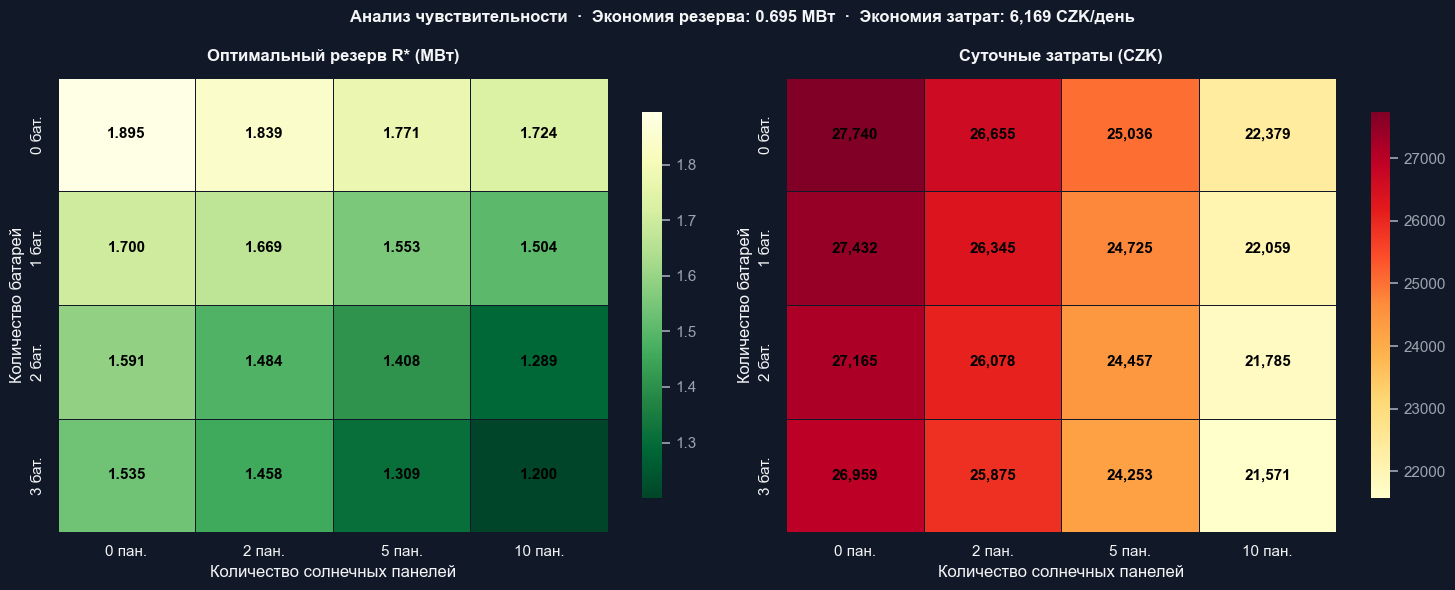

✓ График сохранён: 03_sensitivity.png


In [11]:
# ── Heatmaps через seaborn ─────────────────────────────────────────────────
fig, (ax_r, ax_c) = plt.subplots(1, 2, figsize=(15, 6), facecolor=DARK["bg"])

for ax, data, title, fmt, cmap_name in [
    (ax_r, R_grid,    "Оптимальный резерв R* (МВт)",  ".3f",   "YlGn_r"),
    (ax_c, cost_grid, "Суточные затраты (CZK)",        ",.0f",  "YlOrRd"),
]:
    df_heat = pd.DataFrame(
        data,
        index   = [f"{n} бат." for n in n_bat_range],
        columns = [f"{n} пан."  for n in n_panels_range],
    )
    sns.heatmap(
        df_heat, ax=ax, annot=True, fmt=fmt, cmap=cmap_name,
        linewidths=0.5, linecolor=DARK["bg"],
        annot_kws={"size": 11, "weight": "bold", "color": "black"},
        cbar_kws={"shrink": 0.85},
    )
    ax.set_title(title, fontsize=12, fontweight="bold",
                 color=DARK["text"], pad=12)
    ax.set_xlabel("Количество солнечных панелей", color=DARK["text"])
    ax.set_ylabel("Количество батарей",           color=DARK["text"])
    ax.tick_params(colors=DARK["text"])
    ax.figure.axes[-1].tick_params(colors=DARK["sub"])

# Аннотация экономии
saving_r    = R_grid[0, 0] - R_grid[-1, -1]
saving_cost = cost_grid[0, 0] - cost_grid[-1, -1]
fig.suptitle(
    f"Анализ чувствительности  ·  Экономия резерва: {saving_r:.3f} МВт  ·  Экономия затрат: {saving_cost:,.0f} CZK/день",
    color=DARK["text"], fontsize=12, fontweight="bold",
)
plt.tight_layout()
plt.savefig("03_sensitivity.png", dpi=150, bbox_inches="tight", facecolor=DARK["bg"])
plt.show()
print("✓ График сохранён: 03_sensitivity.png")



## 7. Выводы и интерпретация

### 7.1 Как читать результаты

**Оптимальный резерв R*** — это число которое нужно подать в заявке ERU на следующий месяц.

Если `R* = 1.353 МВт`, это означает:
- Резервируем **1.353 МВт** у сетевого оператора
- В 95%+ случаев этого достаточно — штрафов не будет
- Переплачиваем за резерв меньше, чем если бы взяли 1.9 МВт (без оптимизации)

### 7.2 Что показывает анализ чувствительности

```
         0 панелей   5 панелей   10 панелей
0 батарей:  1.895 МВт → 1.771 МВт → 1.724 МВт   (только панели снижают пик)
2 батареи:  1.591 МВт → 1.408 МВт → 1.289 МВт   (батареи + панели = макс. эффект)
3 батареи:  1.535 МВт → 1.309 МВт → 1.200 МВт
```

**Вывод:** каждая дополнительная батарея снижает R* примерно на 0.1-0.2 МВт.  
При тарифе 450 CZK/МВт/день экономия от одной батареи составляет ~2,025 CZK/месяц.

### 7.3 Следующие шаги

| Приоритет | Действие |
|-----------|---------|
| 🔴 Высокий | Подключить реальный OTE API — заменить `generate_prices()` |
| 🔴 Высокий | Установить умный счётчик — заменить `generate_demand_scenarios()` |
| 🟡 Средний | Подключить pvlib + PVGIS — заменить `generate_solar_scenarios()` |
| 🟢 Низкий  | Добавить бинарные переменные (MILP) — запрет одновременного заряда/разряда |
| 🟢 Низкий  | Расширить до месячного горизонта с MPC (rolling window) |

### 7.4 Замена синтетических данных на реальные

```python
# Сейчас (синтетика):
prices = generate_prices(date, T)

# Будущее (реальные данные OTE):
import requests
resp   = requests.get(f"https://www.ote-cr.cz/api/day-ahead?date={date}")
prices = np.array([item["price"] for item in resp.json()["data"]])
# Модель и вся визуализация ниже — без изменений
```
